# Train EForm Excel Table Extractor — máy cá nhân (`train.ipynb`)

Chọn **Run All**. Notebook tự tạo môi trường Python 3.12 riêng trong `Train/.venv` vì PyTorch Windows chưa hỗ trợ Python 3.14. Kernel hiện tại của bạn vẫn có thể là Python 3.14.7.

Mạng U-Net 2D học ba lớp cell: `outside`, `header`, `value`. Artifact cuối cùng là một file `eform_excel_table_extractor_v1.eformmodel`.

In [1]:
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys

def find_module_root():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'Data' / 'dataset.jsonl').is_file() and (candidate / 'Train' / 'training_core.py').is_file():
            return candidate
    raise FileNotFoundError('Không tìm thấy Data/dataset.jsonl và Train/training_core.py')

MODULE_ROOT = find_module_root()
TRAIN_ROOT = MODULE_ROOT / 'Train'
OUTPUT_DIR = TRAIN_ROOT / 'Output_Local'
MODEL_FILE = OUTPUT_DIR / 'eform_excel_table_extractor_v1.eformmodel'

# ================= CẤU HÌNH CÓ THỂ CHỈNH BẰNG TAY =================
# Thông dụng nhất: EPOCHS, BATCH_SIZE, LEARNING_RATE và PATIENCE.
EPOCHS = 20
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
MIN_DELTA = 1e-5
GRADIENT_CLIP_NORM = 2.0
BASE_CHANNELS = 32  # 16: nhẹ hơn; 32: mặc định; 48/64: mạnh nhưng chậm hơn.
CLASS_WEIGHTS = (0.25, 1.0, 1.15)  # outside, header, value
DEVICE = 'auto'  # auto hoặc cpu; local hiện cài PyTorch CPU.
NUM_WORKERS = 0  # Windows nên giữ 0; chỉ tăng khi đã kiểm thử ổn định.
MIN_COMPONENT_CELLS = 4
HEADER_FRACTION_THRESHOLD = 0.30
DEMO_SAMPLES = 6
SEED = 20260913
LIMIT_PER_SPLIT = 0  # 0 = dùng toàn bộ dataset.
SMOKE_TEST = False  # True: chạy nhanh 1 epoch trên ít file để kiểm tra môi trường.
# ===================================================================

print('Module root:', MODULE_ROOT)
print('Output model:', MODEL_FILE)

Module root: C:\Users\hoang\Downloads\eform_btp\Module\AI Import
Output model: C:\Users\hoang\Downloads\eform_btp\Module\AI Import\Train\Output_Local\eform_excel_table_extractor_v1.eformmodel


## 1. Chuẩn bị runtime PyTorch local

Môi trường này chỉ phục vụ train, tách khỏi Python 3.14.7 và được tái sử dụng ở các lần chạy sau.

In [2]:
UV = shutil.which('uv') or str(Path.home() / '.local' / 'bin' / 'uv.exe')
if not Path(UV).is_file():
    raise FileNotFoundError('Không tìm thấy uv. Cài bằng: powershell -c \"irm https://astral.sh/uv/install.ps1 | iex\"')

VENV_DIR = TRAIN_ROOT / '.venv'
TRAIN_PYTHON = VENV_DIR / 'Scripts' / 'python.exe'
if not TRAIN_PYTHON.is_file():
    subprocess.check_call([UV, 'venv', '--python', '3.12', str(VENV_DIR)])

dependency_check = subprocess.run(
    [str(TRAIN_PYTHON), '-c', 'import torch,openpyxl,matplotlib,tqdm; assert tuple(map(int, torch.__version__.split("+")[0].split(".")[:2])) >= (2,8)'],
    capture_output=True, text=True,
)
if dependency_check.returncode != 0:
    subprocess.check_call([
        UV, 'pip', 'install', '--python', str(TRAIN_PYTHON),
        '--index-url', 'https://download.pytorch.org/whl/cpu', 'torch==2.8.0',
    ])
    subprocess.check_call([
        UV, 'pip', 'install', '--python', str(TRAIN_PYTHON),
        'openpyxl==3.1.5', 'matplotlib>=3.9,<4', 'tqdm>=4.66,<5',
    ])

versions = subprocess.check_output(
    [str(TRAIN_PYTHON), '-c', 'import sys,torch; print(sys.version.split()[0]); print(torch.__version__); print(torch.cuda.is_available())'],
    text=True, encoding='utf-8',
).splitlines()
print('Train Python:', versions[0])
print('PyTorch:', versions[1])
print('CUDA:', versions[2], '(bản local dùng CPU ổn định; Colab dùng GPU)')

Train Python: 3.12.13
PyTorch: 2.8.0+cpu
CUDA: False (bản local dùng CPU ổn định; Colab dùng GPU)


## 2. Train theo batch/epoch và validation

Mỗi epoch in loss, cell accuracy, macro-F1, table IoU và box IoU. Early stopping chọn epoch tốt nhất theo IoU của header/value trên validation.

In [5]:
epochs = 1 if SMOKE_TEST else EPOCHS
limit_per_split = 8 if SMOKE_TEST else LIMIT_PER_SPLIT
command = [
    str(TRAIN_PYTHON), str(TRAIN_ROOT / 'training_core.py'),
    '--module-root', str(MODULE_ROOT),
    '--output-dir', str(OUTPUT_DIR),
    '--epochs', str(epochs),
    '--batch-size', str(BATCH_SIZE),
    '--learning-rate', str(LEARNING_RATE),
    '--weight-decay', str(WEIGHT_DECAY),
    '--patience', str(PATIENCE),
    '--min-delta', str(MIN_DELTA),
    '--gradient-clip-norm', str(GRADIENT_CLIP_NORM),
    '--base-channels', str(BASE_CHANNELS),
    '--class-weights', *[str(value) for value in CLASS_WEIGHTS],
    '--device', DEVICE,
    '--num-workers', str(NUM_WORKERS),
    '--minimum-component-cells', str(MIN_COMPONENT_CELLS),
    '--header-fraction-threshold', str(HEADER_FRACTION_THRESHOLD),
    '--seed', str(SEED),
    '--demo-samples', str(DEMO_SAMPLES),
    '--limit-per-split', str(limit_per_split),
]

environment = os.environ.copy()
environment['PYTHONUTF8'] = '1'
environment['MPLBACKEND'] = 'Agg'
process = subprocess.Popen(
    command, cwd=str(MODULE_ROOT), env=environment,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, encoding='utf-8', errors='replace', bufsize=1,
)
for output_line in process.stdout:
    print(output_line, end='')
return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f'Train thất bại, exit code={return_code}')
assert MODEL_FILE.is_file(), MODEL_FILE
print('TRAIN_SUCCESS:', MODEL_FILE)

Device: cpu
PyTorch: 2.8.0+cpu
Samples: {'train': 694, 'validation': 71, 'test_id': 130, 'test_ood': 34}
Parameters: 379,107
Batch size: 8; batches/epoch: 209; epochs: 20

Epoch 01/20 train: 100%|██████████| 209/209 [03:50<00:00,  1.09it/s, batch=209/209, loss=0.0023]
                                                                                                

Epoch 01/20 val: 100%|██████████| 9/9 [00:07<00:00,  1.66it/s, batch=9/9, loss=0.3722]
                                                                                      
Epoch 01/20 | train_loss=0.0548 | val_loss=0.1204 | val_acc=0.9792 | val_macro_f1=0.9768 | val_table_iou=0.9786 | val_box_iou=0.8273

Epoch 02/20 train: 100%|██████████| 209/209 [02:28<00:00,  1.37it/s, batch=209/209, loss=0.0037]
                                                                                                

Epoch 02/20 val:  89%|████████▉ | 8/9 [00:01<00:00,  8.42it/s, batch=9/9, loss=0.1343]
                                           

## 3. Đánh giá validation, Test-ID và Test-OOD

{
  "model_file": "C:\\Users\\hoang\\Downloads\\eform_btp\\Module\\AI Import\\Train\\Output_Local\\eform_excel_table_extractor_v1.eformmodel",
  "device": "cpu",
  "parameter_count": 379107,
  "effective_train_samples": 1670,
  "training_config": {
    "epochs_requested": 20,
    "epochs_completed": 14,
    "best_epoch": 9,
    "batch_size": 8,
    "learning_rate": 0.001,
    "patience": 5,
    "seed": 20260913,
    "limit_per_split": 0
  },
  "validation": {
    "cell_accuracy": 0.99618935165307,
    "outside_precision": 1.0,
    "outside_recall": 0.9835982841281857,
    "outside_f1": 0.9917313318916169,
    "outside_iou": 0.9835982841281857,
    "header_precision": 1.0,
    "header_recall": 0.9983593109105825,
    "header_f1": 0.9991789819376027,
    "header_iou": 0.9983593109105825,
    "value_precision": 0.9935937922945051,
    "value_recall": 1.0,
    "value_f1": 0.9967866033039149,
    "value_iou": 0.9935937922945051,
    "foreground_iou": 0.9955884349124474,
    "macro_f1": 0.99

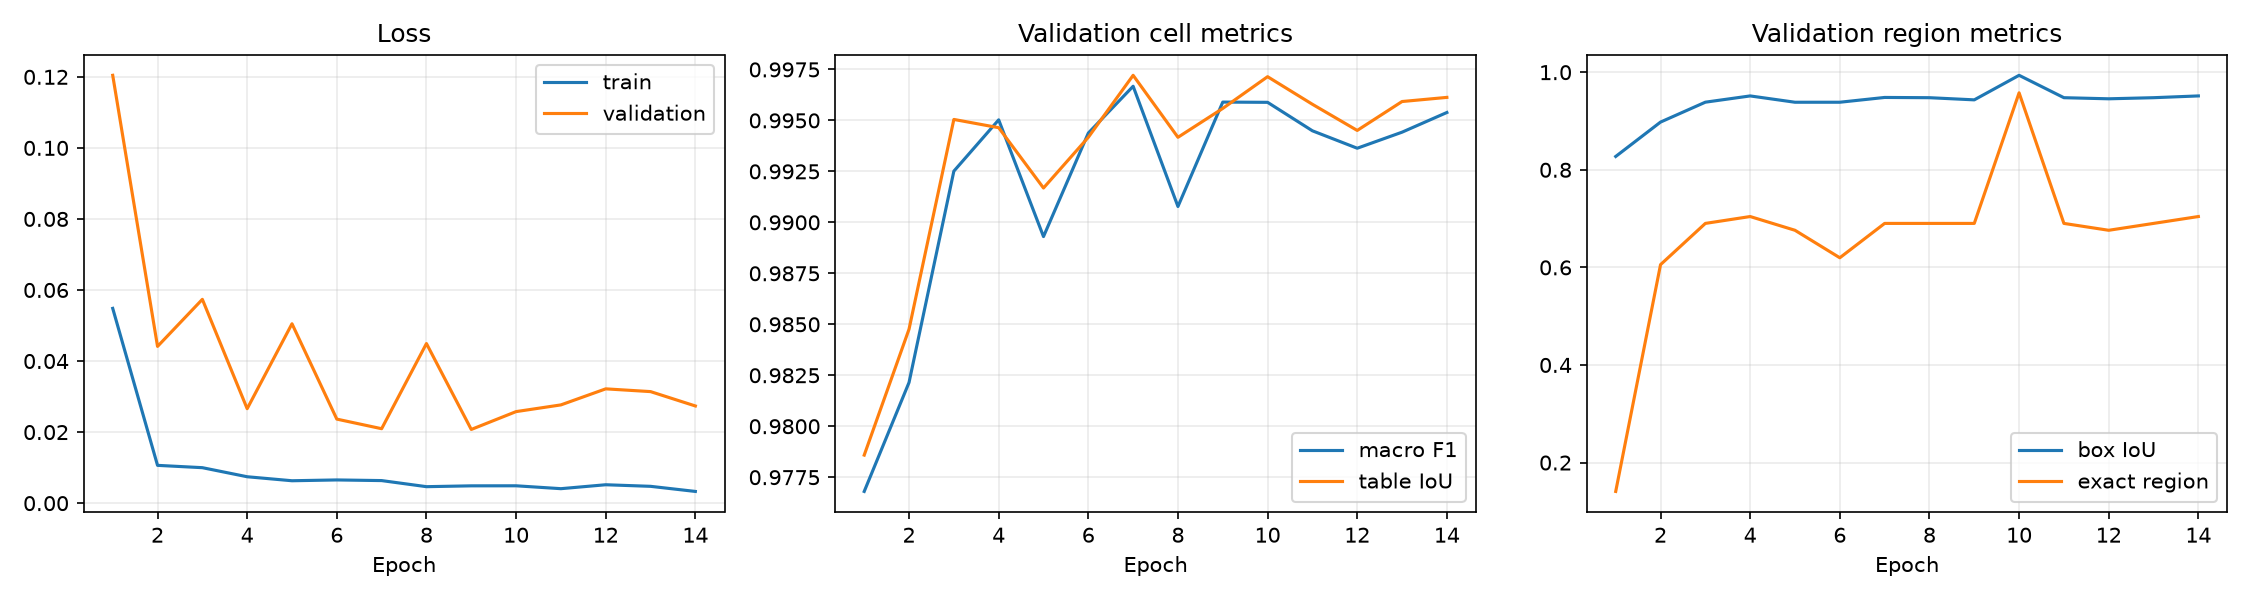

Chứng thực bản sao từ bản chính,,,"Chứng thực chữ ký trong giấy tờ, văn bản",,Chứng thực chữ ký người dịch,,"Số việc chứng thực hợp đồng, giao dịch",
Số lượng bản sao được chứng thực (Bản),,Phí chứng thực bản sao(Đồng),"Số việc chứng thực chữ ký trong giấy tờ, văn bản (Việc)","Phí chứng thực chữ ký trong giấy tờ, văn bản (Đồng)",Số việc chứng thực chữ ký người dịch(Việc),Phí chứng thực chữ ký người dịch(Đồng),"Số việc chứng thực hợp đồng, giao dịch(Việc)","Phí chứng thực hợp đồng, giao dịch (Đồng)"
Tổng số,Trong đó: Chứng thực bản sao điện tử từ bản chính,,,,,,,
(1),(2),(3),(4),(5),(6),(7),(8),(9)
5987,2332,21605000,760,7600000,0,0,350,7000000
Chứng thực bản sao từ bản chính,,,"Chứng thực chữ ký trong giấy tờ, văn bản",,Chứng thực chữ ký người dịch,,"Số việc chứng thực hợp đồng, giao dịch",
Số lượng bản sao được chứng thực (Bản),,Phí chứng thực bản sao(Đồng),"Số việc chứng thực chữ ký trong giấy tờ, văn bản (Việc)","Phí chứng thực chữ ký trong giấy tờ, văn bản (Đồng)",Số việc chứng thực chữ ký người dịch(Việc),Phí chứng thực chữ ký người dịch(Đồng),"Số việc chứng thực hợp đồng, giao dịch(Việc)","Phí chứng thực hợp đồng, giao dịch (Đồng)"
Tổng số,Trong đó: Chứng thực bản sao điện tử từ bản chính,,,,,,,
(1),(2),(3),(4),(5),(6),(7),(8),(9)
5987,2332,21605000,760,7600000,0,0,350,7000000
,,,,,,,,


In [6]:
from IPython.display import HTML, Image, display

REPORT_FILE = OUTPUT_DIR / 'training_report.json'
report = json.loads(REPORT_FILE.read_text(encoding='utf-8'))
summary = {
    'model_file': report['model_file'],
    'device': report['device'],
    'parameter_count': report['parameter_count'],
    'effective_train_samples': report['effective_train_samples'],
    'training_config': report['training_config'],
    'validation': report['metrics']['validation'],
    'test_id': report['metrics']['test_id'],
    'test_ood': report['metrics']['test_ood'],
    'artifact_reload_verified': report['artifact_reload_verified'],
}
print(json.dumps(summary, ensure_ascii=False, indent=2))
display(Image(filename=str(OUTPUT_DIR / 'training_curves.png')))
display(HTML((OUTPUT_DIR / 'expected_vs_actual.html').read_text(encoding='utf-8')))

## 4. Nạp đúng file model và dự đoán một file Raw thực tế

Cell này chạy `predict_excel()` bằng artifact vừa lưu. Kết quả đã chứa `sourceRange`, `headerRows`, `data`, `mergeCells` và confidence; backend sau này chỉ cần trả JSON này.

In [7]:
demo_source = MODULE_ROOT / report['random_test_demos'][0]['source_file']
inference_program = (
    'import json,sys; from pathlib import Path; '
    'sys.path.insert(0, sys.argv[1]); '
    'from training_core import predict_excel; '
    'result=predict_excel(Path(sys.argv[2]),Path(sys.argv[3]),"cpu"); '
    'print(json.dumps(result,ensure_ascii=False))'
)
completed = subprocess.run(
    [str(TRAIN_PYTHON), '-c', inference_program, str(TRAIN_ROOT), str(MODEL_FILE), str(demo_source)],
    capture_output=True, text=True, encoding='utf-8', errors='replace', check=True,
)
actual_result = json.loads(completed.stdout)
print('INPUT:', demo_source.name)
print('MODEL:', actual_result['model'])
print('SHEETS:', len(actual_result['sheets']))
print('TABLES:', sum(len(sheet['tables']) for sheet in actual_result['sheets']))
if actual_result['sheets'] and actual_result['sheets'][0]['tables']:
    first_table = actual_result['sheets'][0]['tables'][0]
    print('ACTUAL RANGE:', first_table['sourceRange'])
    print('HEADER ROWS:', first_table['headerRows'])
    print('FIRST ROW:', first_table['data'][0])
actual_result

INPUT: UBND Xã Trung Chính_09a_TP_CT_Kết quả chứng thực tại Ủy ban nhân dân (UBND)(...).xlsx
MODEL: eform_excel_table_extractor_v1
SHEETS: 1
TABLES: 1
ACTUAL RANGE: A3:I10
HEADER ROWS: 4
FIRST ROW: ['Chứng thực bản sao từ bản chính', None, None, 'Chứng thực chữ ký trong giấy tờ, văn bản', None, 'Chứng thực chữ ký người dịch', None, 'Số việc chứng thực hợp đồng, giao dịch', None]


{'model': 'eform_excel_table_extractor_v1',
 'modelFormat': 'eformmodel-1.0',
 'sourceFile': 'UBND Xã Trung Chính_09a_TP_CT_Kết quả chứng thực tại Ủy ban nhân dân (UBND)(...).xlsx',
 'sheets': [{'sheetName': '9a',
   'tables': [{'sourceRange': 'A3:I10',
     'headerRows': 4,
     'data': [['Chứng thực bản sao từ bản chính',
       None,
       None,
       'Chứng thực chữ ký trong giấy tờ, văn bản',
       None,
       'Chứng thực chữ ký người dịch',
       None,
       'Số việc chứng thực hợp đồng, giao dịch',
       None],
      ['Số lượng bản sao được chứng thực \n(Bản)',
       None,
       'Phí chứng thực\n bản sao\n(Đồng)',
       'Số việc chứng thực chữ ký trong giấy tờ, văn bản (Việc)',
       'Phí chứng thực chữ ký trong giấy tờ, văn bản \n(Đồng)',
       'Số việc chứng thực chữ ký người dịch\n(Việc)',
       'Phí chứng thực chữ ký người dịch\n(Đồng)',
       'Số việc chứng thực hợp đồng, giao dịch\n(Việc)',
       'Phí chứng thực hợp đồng, giao dịch\n (Đồng)'],
      ['Tổng s

## Hoàn tất

Model: `Train/Output_Local/eform_excel_table_extractor_v1.eformmodel`. Báo cáo, đường cong train và so sánh mong đợi/thực tế nằm cùng thư mục Output_Local.